# **Assignment 1 Data Management: Iris Classification using Spark MLlib**

- This assignment focuses on a classification task using the Iris dataset.
- The goal is to classify Iris flower species based on four numerical features: sepal length, sepal width, petal length, and petal width.
- Three classification algorithms are implemented using Spark MLlib:
  1. Logistic Regression  
  2. Decision Tree  
  3. Random Forest  
- Model tuning is carried out using cross-validation and grid search
- The models are evaluated using accuracy, precision, recall, and F1-score.

***Table 1: Iris Dataset Attributes***

| Attribute | Description | Type |
|---|---|---|
| sepal_length | Length of the sepal | Numerical |
| sepal_width | Width of the sepal | Numerical |
| petal_length | Length of the petal | Numerical |
| petal_width | Width of the petal | Numerical |
| species | Iris flower species | Categorical |


# **1.0 Load Libraries and Create Spark Session**

The required libraries are imported in this section. SparkSession is used to start Spark in the local machine, while Spark MLlib libraries are used for feature preparation, classification models, model tuning, and model evaluation.


In [98]:
# Import Spark session
from pyspark.sql import SparkSession

# Import Spark column function
from pyspark.sql.functions import col

# Import Spark ML feature tools
from pyspark.ml.feature import VectorAssembler, StringIndexer

# Import Spark ML classification models
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier

# Import Spark ML evaluation and tuning tools
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Import libraries for visualization
import pandas as pd
import matplotlib.pyplot as plt


In [99]:
# Create Spark session
# local[1] is used because it is more stable on Windows
spark = SparkSession.builder \
    .appName("Iris Classification") \
    .master("local[1]") \
    .config("spark.sql.shuffle.partitions", "1") \
    .config("spark.default.parallelism", "1") \
    .config("spark.python.worker.reuse", "false") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .getOrCreate()

print("Spark session created successfully")


Spark session created successfully


# **2.0 Load Dataset and Data Understanding**

The dataset used in this assignment is the original Iris dataset file, `iris.data`. Since this file does not contain column names, the columns are renamed manually after loading the dataset into a Spark DataFrame.


In [100]:
# Load Iris dataset using Spark
iris = spark.read.csv("iris.data", header=False, inferSchema=True)

# Rename columns
iris = iris.withColumnRenamed("_c0", "sepal_length") \
           .withColumnRenamed("_c1", "sepal_width") \
           .withColumnRenamed("_c2", "petal_length") \
           .withColumnRenamed("_c3", "petal_width") \
           .withColumnRenamed("_c4", "species")

# Display column names and data types
print("Data types:",iris.dtypes)

Data types: [('sepal_length', 'double'), ('sepal_width', 'double'), ('petal_length', 'double'), ('petal_width', 'double'), ('species', 'string')]


In [101]:
# Load the same dataset using pandas for display and visualization only
iris_viz = pd.read_csv("iris.data",header=None,
                       names=["sepal_length", "sepal_width", "petal_length", "petal_width", "species"])

iris_viz.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


From the dataset preview, it can be seen that the data consists of four numerical input variables and one categorical target variable. The target variable is species which represents the type of Iris flower.

In [102]:
# Check number of records and columns using pandas for easier display
print("Number of rows:", iris_viz.shape[0])
print("Number of columns:", iris_viz.shape[1])


Number of rows: 150
Number of columns: 5


In [103]:
# Check missing values
iris_viz.isnull().sum()


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

The missing value checking shows whether there are any null values in the dataset. The results show that there are no missing values in the dataset, so no additional data cleaning is required.

# **3.0 Exploratory Data Analysis and Visualization**

Visualization is included to understand the structure of the Iris dataset before building the classification models.


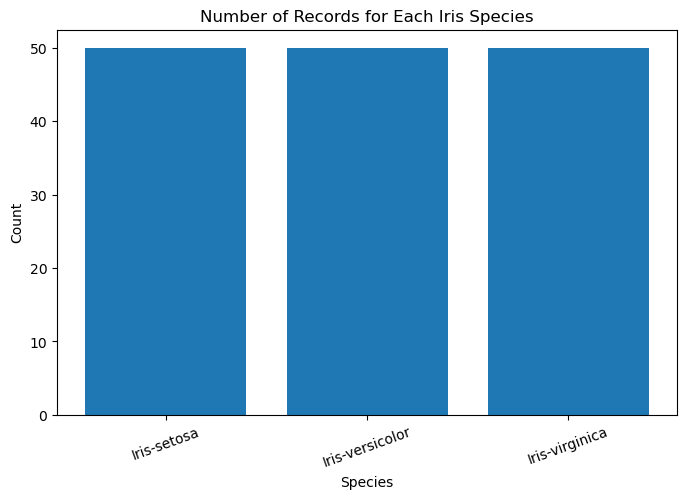

In [104]:
# Count the number of records for each species
species_count = iris_viz["species"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(species_count.index, species_count.values)
plt.xlabel("Species")
plt.ylabel("Count")
plt.title("Number of Records for Each Iris Species")
plt.xticks(rotation=20)
plt.show()


The bar chart shows the number of records for each Iris species. The dataset shows that all species have the same number of records. Hence, it is a balanced dataset. A balanced dataset is useful because the model is trained fairly across all classes.

<Figure size 800x500 with 0 Axes>

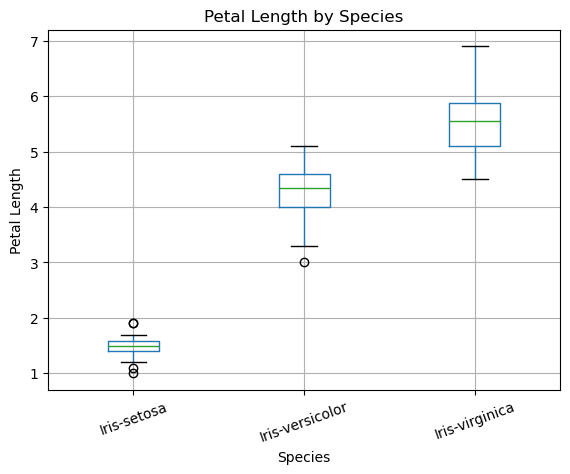

In [105]:
# Boxplot of petal length by species
plt.figure(figsize=(8, 5))
iris_viz.boxplot(column="petal_length", by="species")
plt.title("Petal Length by Species")
plt.suptitle("")
plt.xlabel("Species")
plt.ylabel("Petal Length")
plt.xticks(rotation=20)
plt.show()


The boxplot shows that petal length is useful for separating the Iris species. Iris-setosa has a noticeably shorter petal length than the other species. Iris-virginica has the widest petals among the others. 


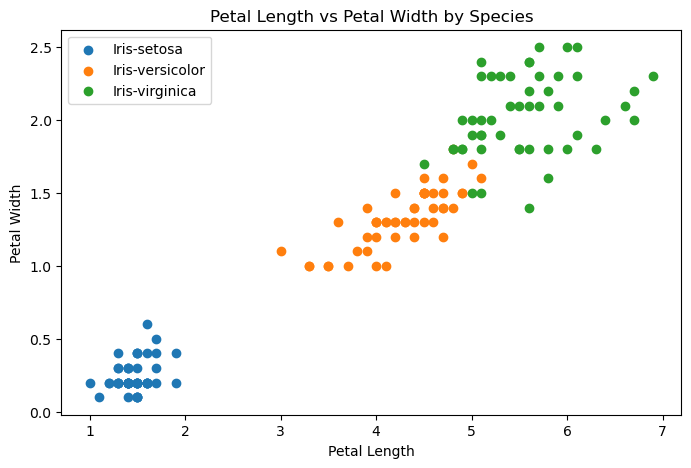

In [106]:
# Scatter plot of petal length and petal width
plt.figure(figsize=(8, 5))

for species in iris_viz["species"].unique():
    subset = iris_viz[iris_viz["species"] == species]
    plt.scatter(subset["petal_length"], subset["petal_width"], label=species)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Length vs Petal Width by Species")
plt.legend()
plt.show()


The scatter plot shows that petal length and petal width are strong features for classifying Iris species. Iris-setosa is clearly separated, while Iris-versicolor and Iris-virginica are closer to each other.


# **4.0 Data Preprocessing for Spark MLlib**

Spark MLlib requires that the categorical variable "species" be converted into a numerical format using StringIndexer and VectorAssembler is used to combine the four numerical features.  This is necessary because machine learning models require numerical input for the target variable. A new column called "label" was created to represent the encoded species values.


In [107]:
# Convert categorical species into numeric label
indexer = StringIndexer(inputCol="species", outputCol="label")
iris = indexer.fit(iris).transform(iris)

iris.select("species", "label").show(10)

+-----------+-----+
|    species|label|
+-----------+-----+
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
+-----------+-----+
only showing top 10 rows


In [108]:
# Combine all feature columns into one vector column
assembler = VectorAssembler(
    inputCols=["sepal_length", "sepal_width", "petal_length", "petal_width"],
    outputCol="features")

iris = assembler.transform(iris)

# Select only the columns needed for modelling
data = iris.select("features", "label")


# **5.0 Train-Test Split**

The dataset is split into training and testing sets. The training data is used to train the models, while the testing data is used to evaluate how well the models perform on unseen data.


In [109]:
# Split dataset into training and testing data
train, test = data.randomSplit([0.7, 0.3], seed=1)

print("Training data:", train.count())
print("Testing data:", test.count())


Training data: 110
Testing data: 40


# **6.0 Model Development and Hyperparameter Tuning**

Three classification models are developed in this section. Cross-validation and grid search are used to tune the hyperparameters of each model. Predictions were generated on the testing dataset using the optimised models. The transform() function was used to produce predicted labels for each observation based on the trained models.


In [110]:
# Define evaluator for model tuning
# Accuracy is used as the main metric
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy")


## **6.1 Logistic Regression**

Logistic Regression is a classification model that estimates the probability of each class. It is simple and efficient, especially when the classes can be separated using a linear boundary.


In [111]:
# Create Logistic Regression model
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100)

# Define hyperparameter grid for Logistic Regression
lr_paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1]) \
    .addGrid(lr.elasticNetParam, [0.0, 1.0]) \
    .build()

# Apply cross-validation
lr_cv = CrossValidator(
    estimator=lr,
    estimatorParamMaps=lr_paramGrid,
    evaluator=evaluator,
    numFolds=2)

# Train Logistic Regression model
lr_model = lr_cv.fit(train)

# Generate predictions on testing data
lr_predictions = lr_model.transform(test)


## **6.2 Decision Tree**

Decision Tree is a tree-based classification model. It works by splitting the data based on decision rules. It is easy to interpret, but may overfit if the tree is too deep.


In [112]:
# Create Decision Tree model
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")

# Define hyperparameter grid for Decision Tree
dt_paramGrid = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [2, 5]) \
    .build()

# Apply cross-validation
dt_cv = CrossValidator(
    estimator=dt,
    estimatorParamMaps=dt_paramGrid,
    evaluator=evaluator,
    numFolds=2)

# Train Decision Tree model
dt_model = dt_cv.fit(train)

# Generate predictions on testing data
dt_predictions = dt_model.transform(test)


## **6.3 Random Forest**

Random Forest is an ensemble method that combines multiple decision trees. It usually improves stability and reduces overfitting compared to a single decision tree.


In [113]:
# Create Random Forest model
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=1)

# Define hyperparameter grid for Random Forest
rf_paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 20]) \
    .addGrid(rf.maxDepth, [2, 5]) \
    .build()

# Apply cross-validation
rf_cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=rf_paramGrid,
    evaluator=evaluator,
    numFolds=2)

# Train Random Forest model
rf_model = rf_cv.fit(train)

# Generate predictions on testing data
rf_predictions = rf_model.transform(test)


# **7.0 Model Evaluation**

The models are evaluated using accuracy, precision, recall, and F1-score because they provide a comprehensive assessment of model performance, especially in classification tasks involving multiple classes. Accuracy measures the overall correct classification rate. Precision measures how accurate the positive predictions are. Recall measures how well the model identifies the actual class. F1-score balances precision and recall.


In [114]:
# Function to calculate evaluation metrics
def evaluate_model(predictions):

    accuracy = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy"
    ).evaluate(predictions)

    precision = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedPrecision"
    ).evaluate(predictions)

    recall = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedRecall"
    ).evaluate(predictions)

    f1 = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1"
    ).evaluate(predictions)

    return accuracy, precision, recall, f1


In [115]:
# Performance comparison using evaluation metrics
lr_accuracy, lr_precision, lr_recall, lr_f1 = evaluate_model(lr_predictions)
dt_accuracy, dt_precision, dt_recall, dt_f1 = evaluate_model(dt_predictions)
rf_accuracy, rf_precision, rf_recall, rf_f1 = evaluate_model(rf_predictions)

print("Model Comparison")
print("----------------")

print("Logistic Regression")
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1-score:", lr_f1)

print("\nDecision Tree")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1-score:", dt_f1)

print("\nRandom Forest")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)


Model Comparison
----------------
Logistic Regression
Accuracy: 0.925
Precision: 0.9273809523809523
Recall: 0.925
F1-score: 0.9253373313343329

Decision Tree
Accuracy: 0.925
Precision: 0.9410714285714286
Recall: 0.925
F1-score: 0.9253333333333333

Random Forest
Accuracy: 0.95
Precision: 0.95
Recall: 0.95
F1-score: 0.95


In [116]:
# Store accuracy values
results = {
    "Logistic Regression": lr_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy}

# Identify best model based on accuracy
best_model = max(results, key=results.get)

print("Best Model:", best_model)
print("Best Accuracy:", results[best_model])


Best Model: Random Forest
Best Accuracy: 0.95


# **8.0 Visualization of Model Performance**

The following visualization compares the accuracy, precision, recall, and F1-score of the three models.


In [117]:
# Create pandas DataFrame for model performance visualization
performance_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [lr_accuracy, dt_accuracy, rf_accuracy],
    "Precision": [lr_precision, dt_precision, rf_precision],
    "Recall": [lr_recall, dt_recall, rf_recall],
    "F1-score": [lr_f1, dt_f1, rf_f1]})

performance_df


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.925,0.927381,0.925,0.925337
1,Decision Tree,0.925,0.941071,0.925,0.925333
2,Random Forest,0.950,0.950000,0.950,0.950000


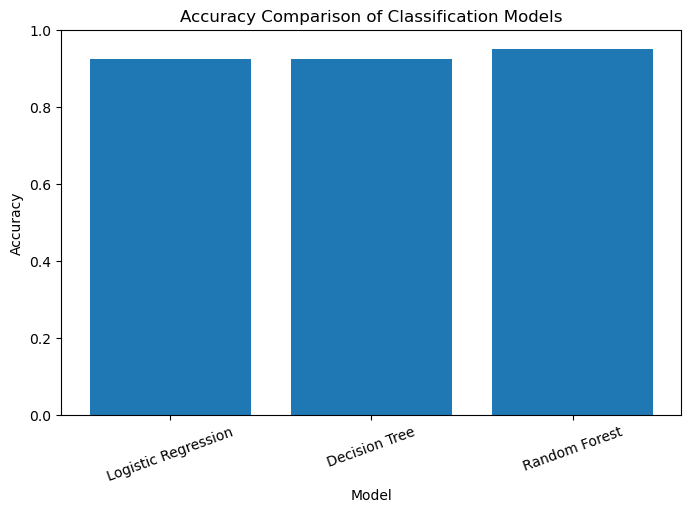

In [118]:
# Plot model accuracy
plt.figure(figsize=(8, 5))
plt.bar(performance_df["Model"], performance_df["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Classification Models")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()


The accuracy comparison reflects the overall performance of each classification model. In this analysis, Logistic Regression and Decision Tree achieved the same accuracy, while Random Forest achieved slightly higher accuracy. However, the differences are minimal, indicating that all models perform similarly. This suggests that the Iris dataset is relatively simple and well-structured, allowing different classification algorithms to achieve comparable performance in distinguishing between the species.


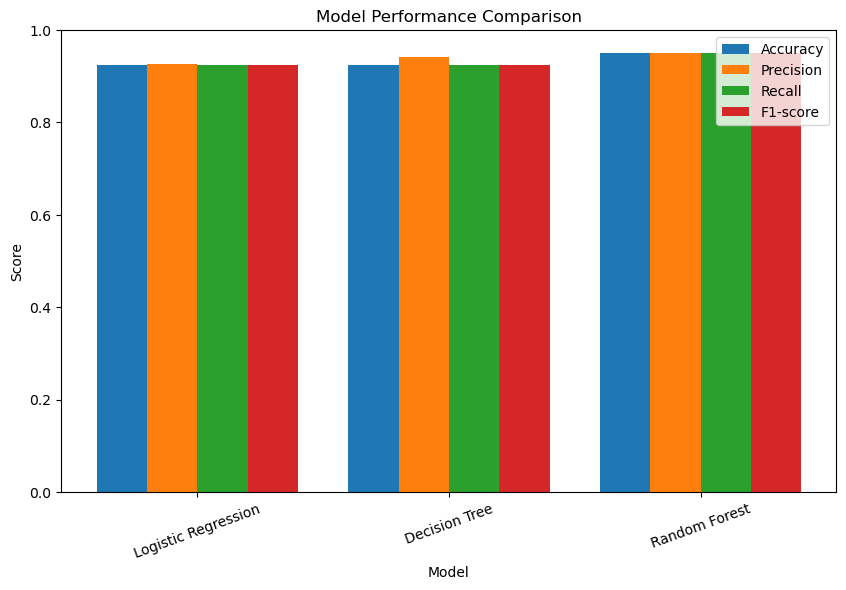

In [119]:
# Plot all evaluation metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

x = range(len(performance_df["Model"]))
width = 0.2

plt.figure(figsize=(10, 6))

for i, metric in enumerate(metrics):
    positions = [p + (i * width) for p in x]
    plt.bar(positions, performance_df[metric], width=width, label=metric)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks([p + width * 1.5 for p in x], performance_df["Model"], rotation=20)
plt.ylim(0, 1)
plt.legend()
plt.show()


# **9.0 Comparative Analysis**

Based on the evaluation results, all three models achieved similar performance in terms of accuracy, precision, recall, and F1-score. This indicates that the Iris dataset is relatively simple and well-structured, allowing different classification algorithms to perform effectively.

Logistic Regression achieved strong performance because the dataset is mostly linearly separable, particularly when using petal length and petal width as features. This allows the model to form a clear decision boundary between the classes.

Decision Tree also performed well as it is capable of capturing non-linear relationships by creating decision rules based on feature values. The model is highly interpretable, as the classification process can be easily understood through its tree structure. However, Decision Tree has a tendency to overfit when the tree becomes too deep or complex.

Random Forest achieved comparable performance by combining multiple decision trees to improve prediction stability and reduce variance. Although Random Forest is generally more robust than a single Decision Tree, the improvement in this case is minimal due to the simplicity and small size of the Iris dataset.

Overall, the results show that simple and more complex models can perform similarly when the dataset is clean and well-separated. This also suggests that the selected features are very effective in distinguishing between the Iris species.


## 9.1 Justification of Best-Performing Model

Although all three models achieved similar performance, Random Forest is selected as the best-performing model. This is because Random Forest combines multiple decision trees, which helps to reduce overfitting and improve model stability.

Compared to Logistic Regression, Random Forest does not assume a linear relationship, making it more flexible. Compared to a single Decision Tree, it provides more reliable predictions by averaging multiple models.

Even though the improvement in accuracy is small in this case, Random Forest is still preferred due to its robustness and ability to perform well across different types of datasets. 

# **10.0 Strengths and Limitations**

Logistic Regression is simple, fast, and performs well when the data is linearly separable. However, it may not perform well for more complex patterns.

Decision Tree is easy to interpret and can handle non-linear relationships. However, it is prone to overfitting if the tree becomes too complex.

Random Forest improves the performance of the Decision Tree by combining multiple trees, which reduces overfitting and improves stability. However, it is less interpretable and requires more computational resources.


# **11.0 Conclusion**

In conclusion, this assignment successfully implemented three classification models using Spark MLlib on the Iris dataset. The dataset was preprocessed, and model tuning was performed using cross-validation and grid search.

The results show that all models achieved strong performance, with only slight differences in evaluation metrics. Random Forest was selected as the best model due to its robustness and ability to reduce overfitting.

Overall, this assignment demonstrates a complete classification workflow using Spark MLlib, including data preprocessing, model training, tuning, evaluation, visualization, and model comparison.
